In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

In [21]:
df = pd.read_csv(r'C:\Users\rashid\Desktop\md_retail_analysis\data\processed\customer_shopping_data_cleaned.csv',
                  parse_dates = ['invoice_date'])
print(df.shape)
df.head()

(99457, 13)


,invoice_no,customer_id,gender,age,category,quantity,price,revenue,payment_method,invoice_date,shopping_mall,invoice_month,invoice_year
0,I138884,C241288,Female,28,Clothing,5,1500.40,7502.00,Credit Card,2022-05-08,Kanyon,5,2022
1,I317333,C111565,Male,21,Shoes,3,1800.51,5401.53,Debit Card,2021-12-12,Forum Istanbul,12,2021
2,I127801,C266599,Male,20,Clothing,1,300.08,300.08,Cash,2021-09-11,Metrocity,9,2021
3,I173702,C988172,Female,66,Shoes,5,3000.85,15004.25,Credit Card,2021-05-16,Metropol AVM,5,2021
4,I337046,C189076,Female,53,Books,4,60.60,242.40,Cash,2021-10-24,Kanyon,10,2021


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  str           
 1   customer_id     99457 non-null  str           
 2   gender          99457 non-null  str           
 3   age             99457 non-null  int64         
 4   category        99457 non-null  str           
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   revenue         99457 non-null  float64       
 8   payment_method  99457 non-null  str           
 9   invoice_date    99457 non-null  datetime64[us]
 10  shopping_mall   99457 non-null  str           
 11  invoice_month   99457 non-null  int64         
 12  invoice_year    99457 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(4), str(6)
memory usage: 9.9 MB


------------------------------------------------------------------------------------------------------

In [23]:
selc = ['category', 'payment_method', 'shopping_mall', 'gender']
for col in selc:
    print(f"=== Spending Analysis by {col.upper()} ===")
    summary = df.groupby(col)['revenue'].agg(
        Total_Spending='sum',
        Average_Spending='mean',
        Transaction_Count='count'
    ).sort_values(by='Total_Spending', ascending=False)
    
    print(summary)
    print("-" * 67 + "\n")

=== Spending Analysis by CATEGORY ===
                 Total_Spending  Average_Spending  Transaction_Count
category                                                            
Clothing           113996791.04           3305.50              34487
Shoes               66553451.47           6632.79              10034
Technology          57862350.00          11581.74               4996
Cosmetics            6792862.90            449.95              15097
Toys                 3980426.24            394.61              10087
Food & Beverage       849535.05             57.49              14776
Books                 834552.90            167.55               4981
Souvenir              635824.65            127.19               4999
-------------------------------------------------------------------

=== Spending Analysis by PAYMENT_METHOD ===
                Total_Spending  Average_Spending  Transaction_Count
payment_method                                                     
Cash              11283

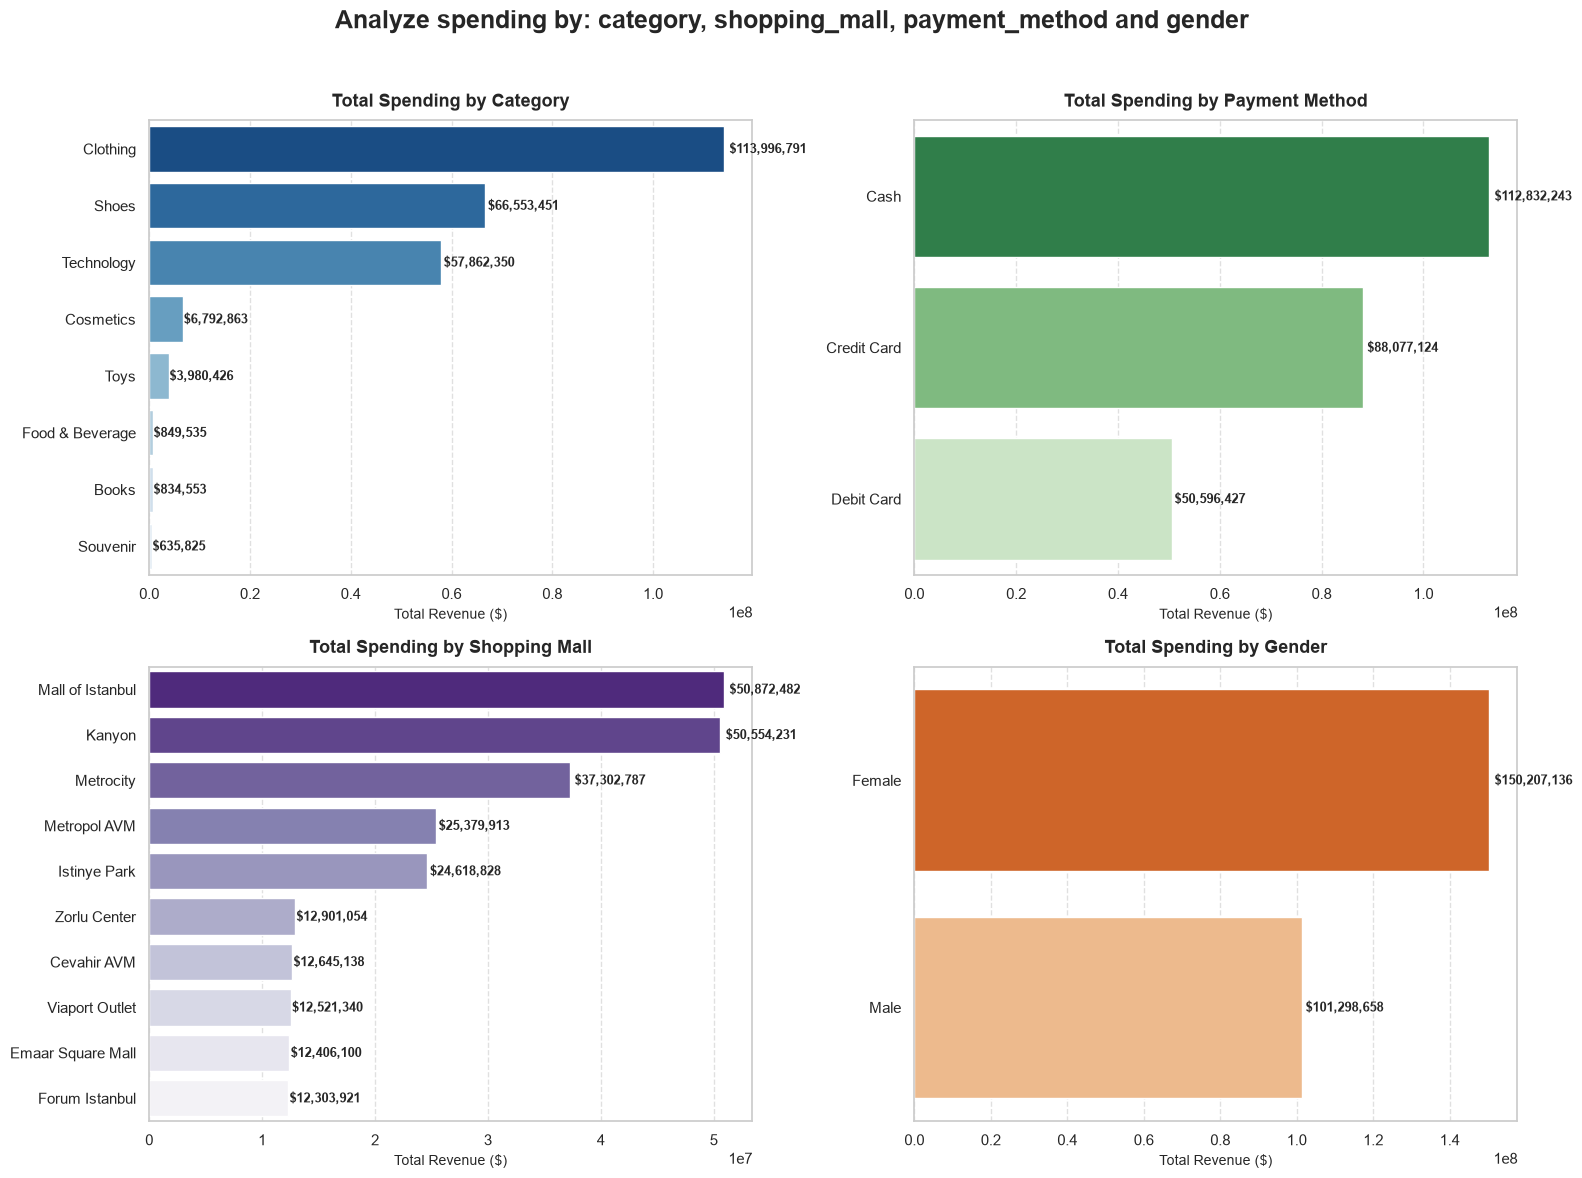

In [24]:
selc = ['category', 'payment_method', 'shopping_mall', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# bu pallettler daha uygun gordum ona gore secdim, isteseniz deyisdirib baxa bilersiniz
palettes = ['Blues_r', 'Greens_r', 'Purples_r', 'Oranges_r']

for i, col in enumerate(selc):
    summary = (
        df.groupby(col)['revenue']
        .sum()
        .reset_index()
        .sort_values(by='revenue', ascending=False)
    )

    sns.barplot(
        data=summary,
        y=col,
        x='revenue',
        ax=axes[i],
        palette=palettes[i],
        orient='h',
    )

    axes[i].set_title(
        f'Total Spending by {col.replace("_", " ").title()}',
        fontsize=13,
        fontweight='bold',
        pad=10,
    )
    axes[i].set_xlabel('Total Revenue ($)', fontsize=10)
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', linestyle='--', alpha=0.6)

    for bar in axes[i].patches:
        width = bar.get_width()
        axes[i].text(
            width * 1.01,
            bar.get_y() + bar.get_height() / 2,
            f'${width:,.0f}',
            va='center',
            fontsize=9,
            fontweight='bold',
        )

plt.suptitle(
    'Analyze spending by: category, shopping_mall, payment_method and gender', fontsize=18, fontweight='bold', y=0.98
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

------------------------------------------------------------------------------------------------------

In [25]:
category_analysis = (
    df.groupby('category')['revenue'].agg(
        Average_Spending='mean'
    ).sort_values(by='Average_Spending', ascending=False)
)

category_analysis['revenue_rank'] = category_analysis['Average_Spending'].rank(ascending=False, method='min').astype(int)
#category_analysis.head(df['category'].nunique())

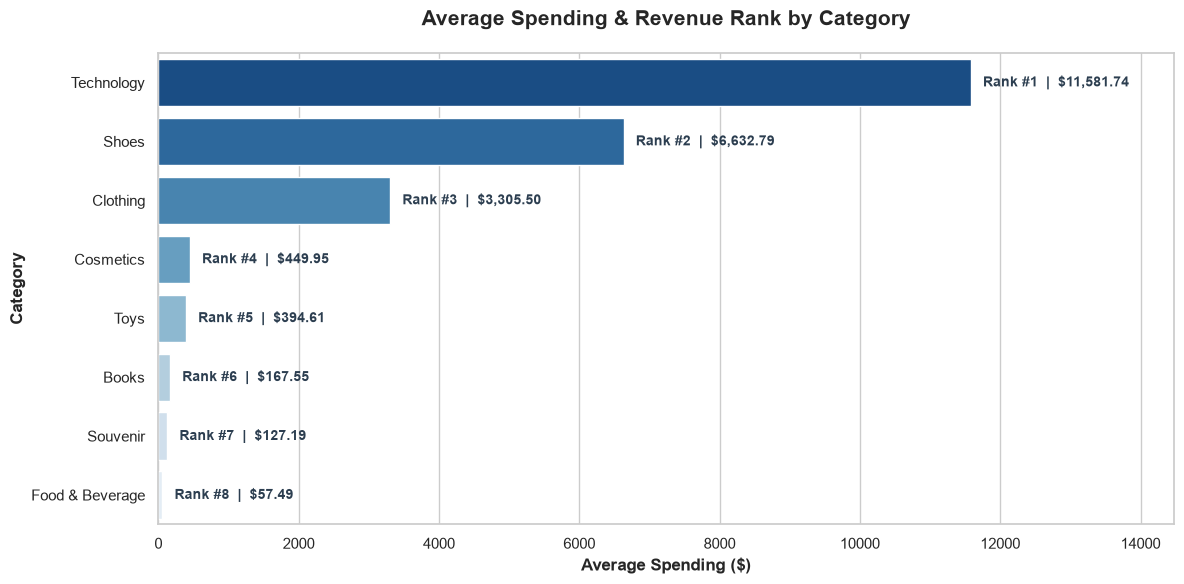

In [26]:
data_to_plot = category_analysis.reset_index()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=data_to_plot,
    y="category",
    x="Average_Spending",
    palette="Blues_r",  
)

# Rank
for i, row in data_to_plot.iterrows():
    rank = row["revenue_rank"]
    avg_val = row["Average_Spending"]

    ax.text(
        avg_val + (data_to_plot["Average_Spending"].max() * 0.01),
        i,
        f" Rank #{rank}  |  ${avg_val:,.2f} ",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#2c3e50",
    )

plt.title(
    "Average Spending & Revenue Rank by Category",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Average Spending ($)", fontsize=12, fontweight="bold")
plt.ylabel("Category", fontsize=12, fontweight="bold")
plt.xlim(0, data_to_plot["Average_Spending"].max() * 1.25)
plt.tight_layout()
plt.show()


------------------------------------------------------------------------------------------------------

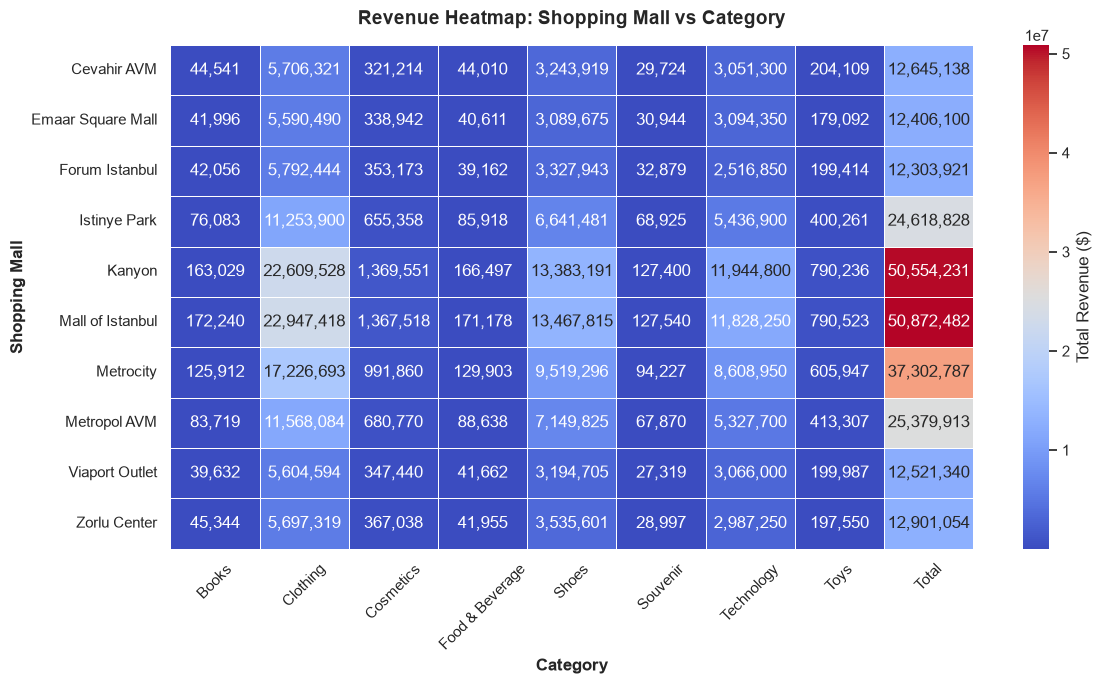

In [27]:
mall_vs_category = pd.pivot_table(
    df,
    values='revenue',
    index='shopping_mall',
    columns='category',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

plot_data = mall_vs_category.drop(index='Total', errors='ignore')

plt.figure(figsize=(12, 7))
sns.heatmap(
    plot_data,
    annot=True,  
    fmt=",.0f",  
    cmap="coolwarm",  # Sarı-Yaşıl-Göy rəng keçidi
    linewidths=0.5,
    cbar_kws={'label': 'Total Revenue ($)'},
)

plt.title(
    'Revenue Heatmap: Shopping Mall vs Category',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Shopping Mall', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------

In [28]:
yearly_category_revenue = (
    df.groupby(['invoice_year', 'category'])['revenue']
    .sum()
    .unstack(level='category')
)

print("=== Yearly Revenue by Category (2021–2023) ===")
print(yearly_category_revenue)

=== Yearly Revenue by Category (2021–2023) ===
category         Books    Clothing  Cosmetics  Food & Beverage       Shoes  \
invoice_year                                                                 
2021         369008.55 52604924.24 3033723.92        390848.36 30125533.15   
2022         391945.65 51753897.36 3150499.44        386852.64 30944765.20   
2023          73598.70  9637969.44  608639.54         71834.05  5483153.12   

category      Souvenir  Technology       Toys  
invoice_year                                   
2021         288288.21 25951800.00 1796444.16  
2022         295865.79 26651100.00 1861888.00  
2023          51670.65  5259450.00  322094.08  


------------------------------------------------------------------------------------------------------

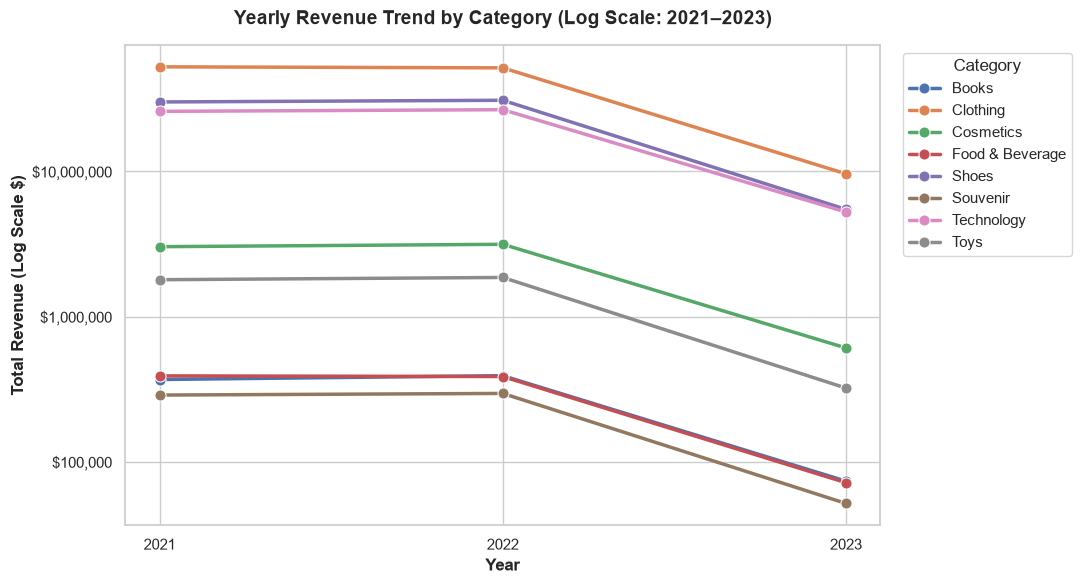

In [29]:
import matplotlib.pyplot as plt

import seaborn as sns

# Datanı vizuallaşdırmaya hazırlayırıq
df_grouped = (
    df.groupby(['invoice_year', 'category'])['revenue'].sum().reset_index()
)

plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

# Qrafiki çəkirik
ax = sns.lineplot(
    data=df_grouped,
    x='invoice_year',
    y='revenue',
    hue='category',
    marker='o',
    markersize=8,
    linewidth=2.5,
)

# 1. Y-oxunu Loqarifmik Şkala edirik
plt.yscale('log')

# 2. X-oxunda YALNIZ [2021, 2022, 2023] illərini göstəririk
plt.xticks(ticks=[2021, 2022, 2023], labels=['2021', '2022', '2023'])

# Y-oxundakı loqarifmik rəqəmləri daha oxunaqlı ($10k, $100k) format edirik
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, _: f'${y:,.0f}')
)

# Başlıq və oxlar
plt.title(
    'Yearly Revenue Trend by Category (Log Scale: 2021–2023)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue (Log Scale $)', fontsize=12, fontweight='bold')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------

In [30]:
gender_analysis = (
    df.groupby(['gender', 'category'])['revenue']
    .sum()
    .unstack(level='category')
)

print("=== Gender Spending Analysis by Category ===")
print(gender_analysis)

=== Gender Spending Analysis by Category ===
category     Books    Clothing  Cosmetics  Food & Beverage       Shoes  \
gender                                                                   
Female   489314.70 68251695.60 4066772.54        505322.60 39425167.30   
Male     345238.20 45745095.44 2726090.36        344212.45 27128284.17   

category  Souvenir  Technology       Toys  
gender                                     
Female   382867.20 34669950.00 2416046.08  
Male     252957.45 23192400.00 1564380.16  


In [ ]:
import plotly.express as px

gender_analysis = df.groupby(['category', 'gender'])['revenue'].sum().reset_index()

fig = px.bar(
    gender_analysis,
    x='category',
    y='revenue',
    color='gender',
    barmode='group',
    title='Gender Spending Analysis by Category',
    labels={'revenue': 'Total Revenue ($)', 'category': 'Category'},
    color_discrete_map={'Female': 'magenta', 'Male': 'mediumblue'},
)

fig.update_layout(template='plotly_white')
fig.show()
"""
Business Insights:
Qadıınların ən çox xərclədiyi kateqoriyalar : Clothing, Shoes, Technology
Satışı qaldırmaq üçün qadınlara yönəlmiş kampaniyalar, endirimlər və məhsul təklifləri daha çox diqqətə alınmalıdır.
Kişi müştərilər üçün isə Technology və Clothing kateqoriyaları daha çox diqqətə alınmalıdır.
"""


'\n\n\n\n'

------------------------------------------------------------------------------------------------------

In [52]:
#Calculate month-over-month revenue growth rate per shopping mall
mom_growth = (
    df.groupby(['shopping_mall','invoice_month'], as_index=False)['revenue']
    .sum()
    .assign(MoM_Growth_Rate_p=lambda x: x.groupby('shopping_mall')['revenue'].pct_change()*100)
    .sort_values(['invoice_month','MoM_Growth_Rate_p'], ascending=True)
)

mom_growth.head(25)


,shopping_mall,invoice_month,revenue,MoM_Growth_Rate_p
0,Cevahir AVM,1,1328345.21,NaN
12,Emaar Square Mall,1,1398164.64,NaN
24,Forum Istanbul,1,1187731.72,NaN
36,Istinye Park,1,2562812.90,NaN
48,Kanyon,1,5037784.80,NaN
60,Mall of Istanbul,1,5290787.50,NaN
72,Metrocity,1,3902610.37,NaN
84,Metropol AVM,1,2582383.35,NaN
96,Viaport Outlet,1,1199785.08,NaN
108,Zorlu Center,1,1265271.88,NaN


------------------------------------------------------------------------------------------------------

In [58]:
category_pay_count = (
    df.groupby(['category', 'payment_method'])
    .size()
    .reset_index(name='transaction_count')
)

category_pay_count['usage_percentage'] = (
    category_pay_count['transaction_count']
    / category_pay_count.groupby('category')['transaction_count'].transform('sum')
) * 100

dominant_payment = (
    category_pay_count.loc[
        category_pay_count.groupby('category')['usage_percentage'].idxmax()
    ]
    .reset_index(drop=True)
    .sort_values(by='usage_percentage', ascending=False)
)
dominant_payment['usage_percentage'] = (
    dominant_payment['usage_percentage'].round(2).astype(str) + '%'
)

print("=== Dominant Payment Method by Usage Percentage ===")
print(dominant_payment)

=== Dominant Payment Method by Usage Percentage ===
          category payment_method  transaction_count usage_percentage
0            Books           Cash               2268           45.53%
7             Toys           Cash               4542           45.03%
1         Clothing           Cash              15456           44.82%
6       Technology           Cash               2235           44.74%
4            Shoes           Cash               4474           44.59%
3  Food & Beverage           Cash               6587           44.58%
5         Souvenir           Cash               2211           44.23%
2        Cosmetics           Cash               6674           44.21%


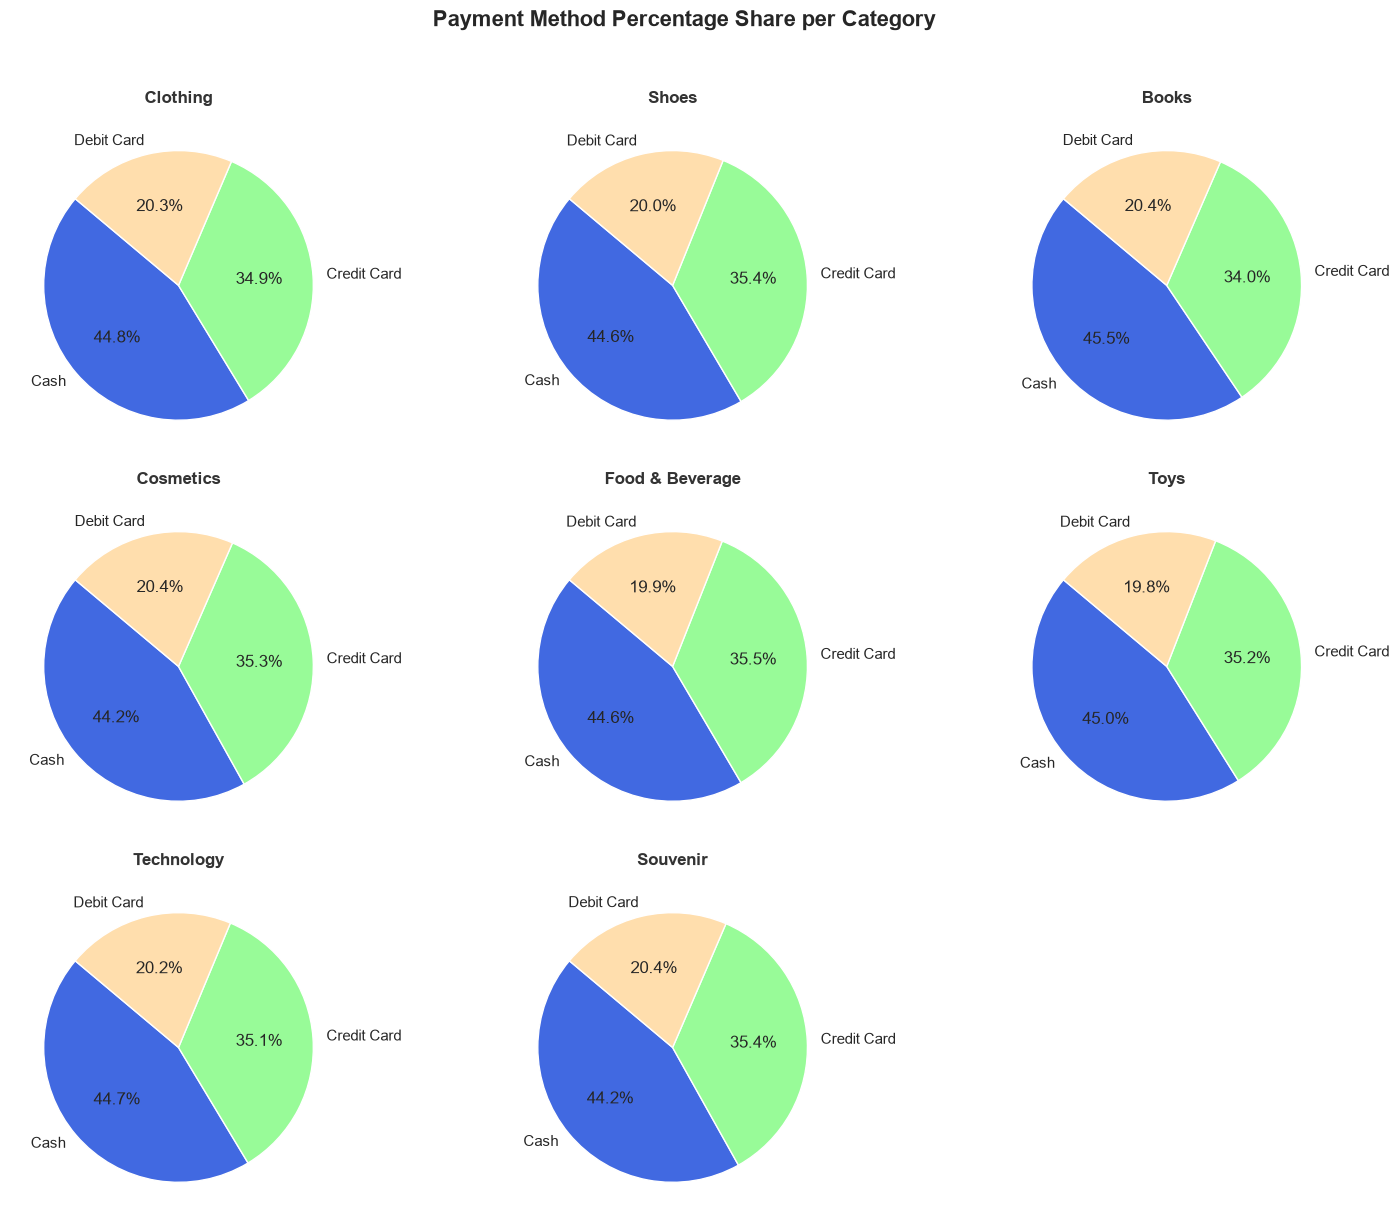

In [70]:
num_cats = len(df['category'].unique())
cols = 3
rows = math.ceil(num_cats / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()


colors = ["royalblue", 'palegreen', 'navajowhite']

for i, cat in enumerate(df['category'].unique()):
    cat_data = df[df['category'] == cat]['payment_method'].value_counts()

    axes[i].pie(
        cat_data,
        labels=cat_data.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        #wedgeprops=dict(width=0.6, edgecolor='w'),  # Donut 
    )
    axes[i].set_title(
        cat, fontsize=12, fontweight='bold', pad=10, color='#333333'
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Payment Method Percentage Share per Category',
    fontsize=16,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------